In [3]:
import kagglehub

# Download latest version
df = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", df)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
df = pd.read_csv(os.path.join(df, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
pd.get_dummies(df)

,SeniorCitizen,tenure,MonthlyCharges,customerID_0002-ORFBO,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_No,Churn_Yes
0,0,1,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0,34,56.95,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,2,53.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,2,70.70,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
7039,0,72,103.20,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
7040,0,11,29.60,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
7041,1,4,74.40,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [9]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Handle TotalCharges: convert to numeric, coercing errors (empty strings) to NaN, then fill NaNs
# The previous output of pd.get_dummies implied TotalCharges was not numeric. We convert it here.
if not pd.api.types.is_numeric_dtype(df['TotalCharges']):
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0) # Fill NaN with 0 or a suitable imputation strategy

# Drop 'customerID' as it's an identifier and not a predictive feature
df_processed = df.drop('customerID', axis=1)

# Convert categorical features to dummy variables
# 'drop_first=True' helps avoid multicollinearity for binary categorical variables.
df_processed = pd.get_dummies(df_processed, drop_first=True)

# Define features (X) and target (y)
# Assuming 'Churn_Yes' is the target column after get_dummies and drop_first
X = df_processed.drop('Churn_Yes', axis=1)
y = df_processed['Churn_Yes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split successfully into training and testing sets.
X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6834 - loss: 3.4274 - val_accuracy: 0.7720 - val_loss: 1.5748
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7289 - loss: 0.9760 - val_accuracy: 0.5359 - val_loss: 0.8189
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7420 - loss: 0.7903 - val_accuracy: 0.6593 - val_loss: 0.5644
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7340 - loss: 0.8465 - val_accuracy: 0.7924 - val_loss: 0.6694
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7397 - loss: 0.8054 - val_accuracy: 0.7870 - val_loss: 0.8926
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7453 - loss: 1.0524 - val_accuracy: 0.7924 - val_loss: 0.5162
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7428 - loss: 1.0508 - val_accuracy: 0.7986 - val_loss: 0.4966
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7590 - loss: 0.6726 - val_accuracy: 0.

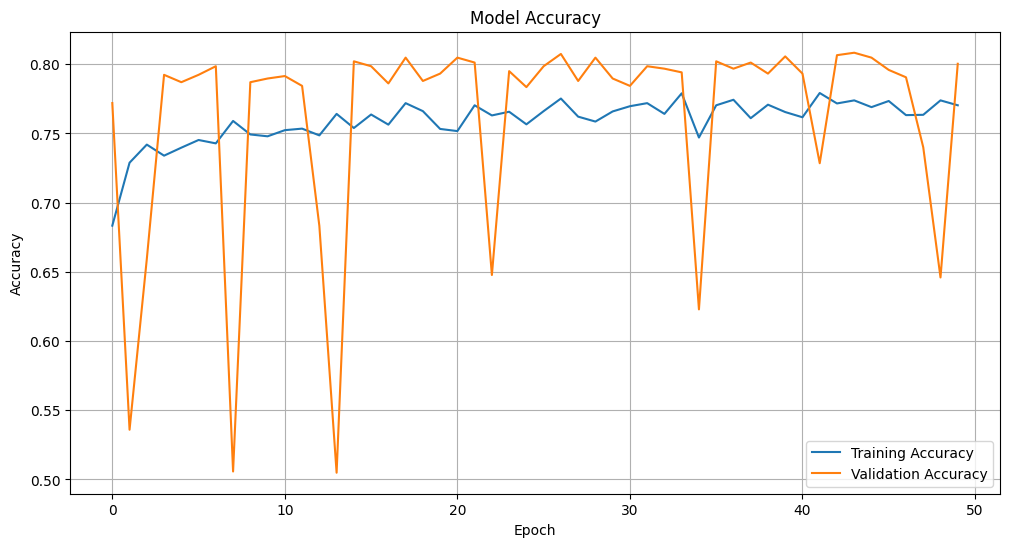

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

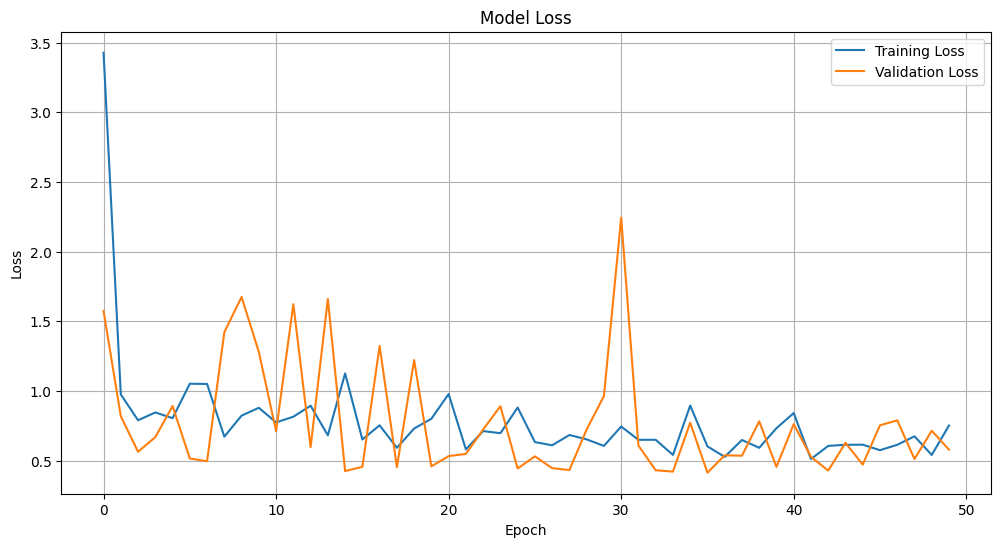

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()